# TCCT S94B — Role-Aware Antisymmetric Readout Development

Development-only stage using revealed S94 labels. Run all cells once. No frozen candidate is overwritten or automatically selected.

Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
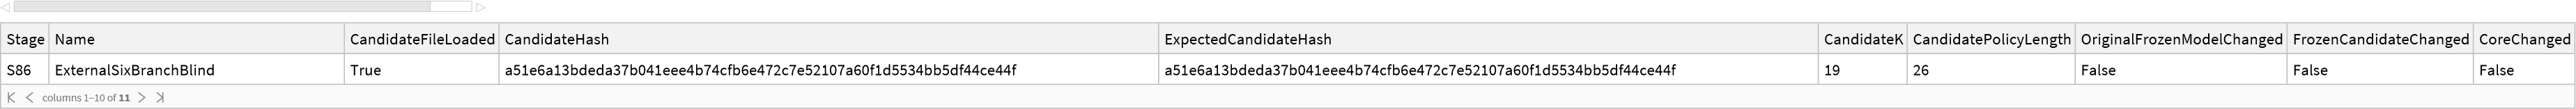

In [1428]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S94B, Name -> RoleAwareReadoutDevelopment, DevelopmentOnly -> True, 
 
>     BlindTest -> False, PreflightPassed -> True, OriginalFrozenModelLocked -> True, 
 
>     S94AAuditLocked -> True, CoreChanged -> False, TrainingRunYet -> False, 
 
>     DevelopmentCasesGeneratedYet -> False, CandidateFrozen -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, DevelopmentOnly, BlindTest, 
 
>      PreflightPassed, OriginalFrozenModelLocked, S94AAuditLocked, CoreChanged, 
 
>      TrainingRunYet, DevelopmentCasesGeneratedYet, CandidateFrozen}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
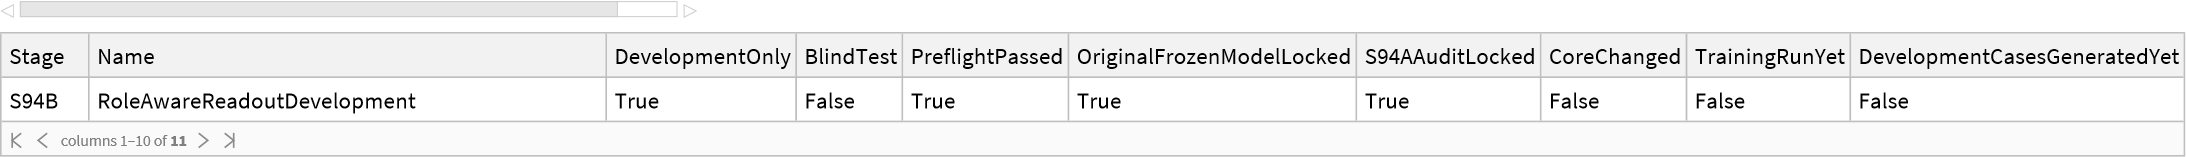

In [1516]:
expectedFrozenModelHash94B=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash94B=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash94B=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedBaseCandidateHash94B=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedBaseCandidateFileHash94B=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedBaseRuntimeFileHash94B=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedPairCandidateHash94B=
"540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c";
expectedPairCandidateFileHash94B=
"aecbe544a4af3a8ad0ba0494bb11312dd4a4b71f1a1c7ae42489a5300c7078ff";
expectedPairRuntimeFileHash94B=
"74a926b8efccaddbd1dd07373ac35a93bc53e9fb08cc456ce1adb6a006d333c6";
expectedS94AAuditFileHash94B=
"ab0f6524f8cb8ee8edb915e132044734f8db8ce20758c09f26ded9de01571571";

k33CandidatePath94B="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
baseRuntimePath94B="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
baseCandidatePath94B="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
pairRuntimePath94B="E:/engine_wolf/TCCT_S92B_PairedContrastDecoderRuntime.wl";
pairCandidatePath94B="E:/engine_wolf/TCCT_S92B_FrozenPairedContrastDecoder.wxf";
s94aAuditPath94B="E:/engine_wolf/TCCT_S94A_ModulusFeasibilityAudit.json";
developmentPairsPath94B="E:/engine_wolf/TCCT_S94B_RoleAwareDevelopmentPairs.wxf";
resultCertificatePath94B="E:/engine_wolf/TCCT_S94B_RoleAwareReadoutDevelopment.json";

ClearAll[FileSHA256Hex94B,CoreDefinitionBundle94B,
PairRuntimeDefinitionBundle94B];
FileSHA256Hex94B[path_String]:=If[FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],Missing["FileMissing",path]];
CoreDefinitionBundle94B[]:=CoreDefinitionBundle86[];
PairRuntimeDefinitionBundle94B[]:={DownValues[TCCTPairContrastVectorS92B],
DownValues[TCCTLoadFrozenPairDecoderS92B],
DownValues[TCCTPredictOrderedPairVectorsS92B],
DownValues[TCCTPredictOrderedPairWorldsS92B]};

requiredFiles94B={k33CandidatePath94B,baseRuntimePath94B,
baseCandidatePath94B,pairRuntimePath94B,pairCandidatePath94B,s94aAuditPath94B};
If[!And@@(FileExistsQ/@requiredFiles94B),
Print["S94B aborted: one or more locked inputs are missing."];
Dataset[AssociationThread[requiredFiles94B,FileExistsQ/@requiredFiles94B]];Abort[]];
If[FileExistsQ[resultCertificatePath94B]&&
FileByteCount[resultCertificatePath94B]>0,
Print["S94B aborted: a prior development certificate exists. Preserve it."];Abort[]];
If[FileExistsQ[developmentPairsPath94B]&&
FileByteCount[developmentPairsPath94B]>0,
Print["S94B aborted: a prior development-pair artifact exists. Preserve it."];Abort[]];

fileHashesBefore94B=FileSHA256Hex94B/@requiredFiles94B;
Clear[frozenCandidate86E];Get[k33CandidatePath94B];
k33HashLoaded94B=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
Get[baseRuntimePath94B];
baseDecoderLoaded94B=Quiet@Check[
TCCTLoadFrozenDecoderS87D[baseCandidatePath94B],$Failed];
baseDecoderRaw94B=If[AssociationQ[baseDecoderLoaded94B],
KeyDrop[baseDecoderLoaded94B,{"Classifier"}],$Failed];
Get[pairRuntimePath94B];
pairDecoderLoaded94B=Quiet@Check[
TCCTLoadFrozenPairDecoderS92B[pairCandidatePath94B],$Failed];
pairDecoderRaw94B=If[AssociationQ[pairDecoderLoaded94B],
KeyDrop[pairDecoderLoaded94B,{"Policy"}],$Failed];
s94aAudit94B=Quiet@Check[Import[s94aAuditPath94B,"RawJSON"],$Failed];

modelHashBefore94B=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore94B=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
baseDecoderObjectHashBefore94B=Hash[Normal[baseDecoderRaw94B],"SHA256","HexString"];
pairDecoderObjectHashBefore94B=Hash[Normal[pairDecoderRaw94B],"SHA256","HexString"];
coreHashBefore94B=Hash[CoreDefinitionBundle94B[],"SHA256","HexString"];
canonicalizerHashBefore94B=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashBefore94B=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashBefore94B=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
baseRuntimeDefinitionHashBefore94B=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
pairRuntimeDefinitionHashBefore94B=Hash[
PairRuntimeDefinitionBundle94B[],"SHA256","HexString"];

preflightPassed94B=And[
SameQ[modelHashBefore94B,expectedFrozenModelHash94B],
SameQ[k33HashLoaded94B,expectedK33CandidateHash94B],
SameQ[fileHashesBefore94B[[1]],expectedK33CandidateFileHash94B],
AssociationQ[baseDecoderLoaded94B],
SameQ[baseDecoderRaw94B["CandidateHash"],expectedBaseCandidateHash94B],
SameQ[fileHashesBefore94B[[2]],expectedBaseRuntimeFileHash94B],
SameQ[fileHashesBefore94B[[3]],expectedBaseCandidateFileHash94B],
AssociationQ[pairDecoderLoaded94B],
SameQ[pairDecoderRaw94B["CandidateHash"],expectedPairCandidateHash94B],
SameQ[fileHashesBefore94B[[4]],expectedPairRuntimeFileHash94B],
SameQ[fileHashesBefore94B[[5]],expectedPairCandidateFileHash94B],
SameQ[fileHashesBefore94B[[6]],expectedS94AAuditFileHash94B],
AssociationQ[s94aAudit94B],
TrueQ[s94aAudit94B["AuditValidityPassed"]],
SameQ[s94aAudit94B["Outcome"],
"S94A_AUDIT_PASS_MODULUS_ALONE_INSUFFICIENT"],
SameQ[s94aAudit94B["CandidateHash"],expectedPairCandidateHash94B]];

preflight94B=<|"Stage"->"S94B","Name"->"RoleAwareReadoutDevelopment",
"DevelopmentOnly"->True,"BlindTest"->False,
"PreflightPassed"->preflightPassed94B,
"OriginalFrozenModelLocked"->SameQ[modelHashBefore94B,expectedFrozenModelHash94B],
"S94AAuditLocked"->SameQ[fileHashesBefore94B[[6]],expectedS94AAuditFileHash94B],
"CoreChanged"->False,"TrainingRunYet"->False,
"DevelopmentCasesGeneratedYet"->False,"CandidateFrozen"->False|>;
If[!TrueQ[preflightPassed94B],Print[Dataset[{preflight94B}]];
Print["S94B aborted: locked-input preflight failed."];Abort[]];
Dataset[{preflight94B}]


Dataset[{<|Stage -> S94B, Name -> RoleAwareReadoutDevelopment, DevelopmentOnly -> True, 
 
>     BlindTest -> False, SourceS94LabelsAlreadyRevealed -> True, 
 
>     CoreMechanismChanged -> False, NewOuterRepresentation -> QuerySemanticRoleSlots, 
 
>     AntisymmetryConstraint -> Score[x,y]==-Score[y,x], BranchCount -> 13, Depth -> 23, 
 
>     Topologies -> 
 
>      {DiamondAfterDoubleAfterHierarchical, HierarchicalAfterDiamondAfterDouble}, 
 
>     NoisePhases -> {0, 1}, TopologyNoiseCrossed -> True, ExpectedScenarios -> 4, 
 
>     ExpectedPairs -> 52, ExpectedWorlds -> 104, 
 
>     Representations -> {Global27, Role30, Combined57}, 
 
>     CandidateFamilies -> {Centroid, DiagonalRidge, FullRidge}, 
 
>     ValidationAxes -> {Topology, NoisePhase, Answer}, DevelopmentPassAccuracy -> 0.95, 
 
>     DevelopmentPassWorstFoldAccuracy -> 0.8, CandidateFrozenAtThisStage -> False, 
 
>     ProtocolHash -> 376cbf7e8a5d1fe039dd64323f1cca4be522e48d34e4a5248872082b4362e9af, 
 
>     TestDefinitionHash -> 
 
>      1ea0f8b521a6a1971847af15a0b427bc74665d0cca9cbc383c5fa8c36b6fe01f, 
 
>     ReadoutDefinitionHash -> 
 
>      07bb48323032cd124fe48ad490e866732281174efe254519f087fc5cd80e1704|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 25], 
 
>    1], <||>]
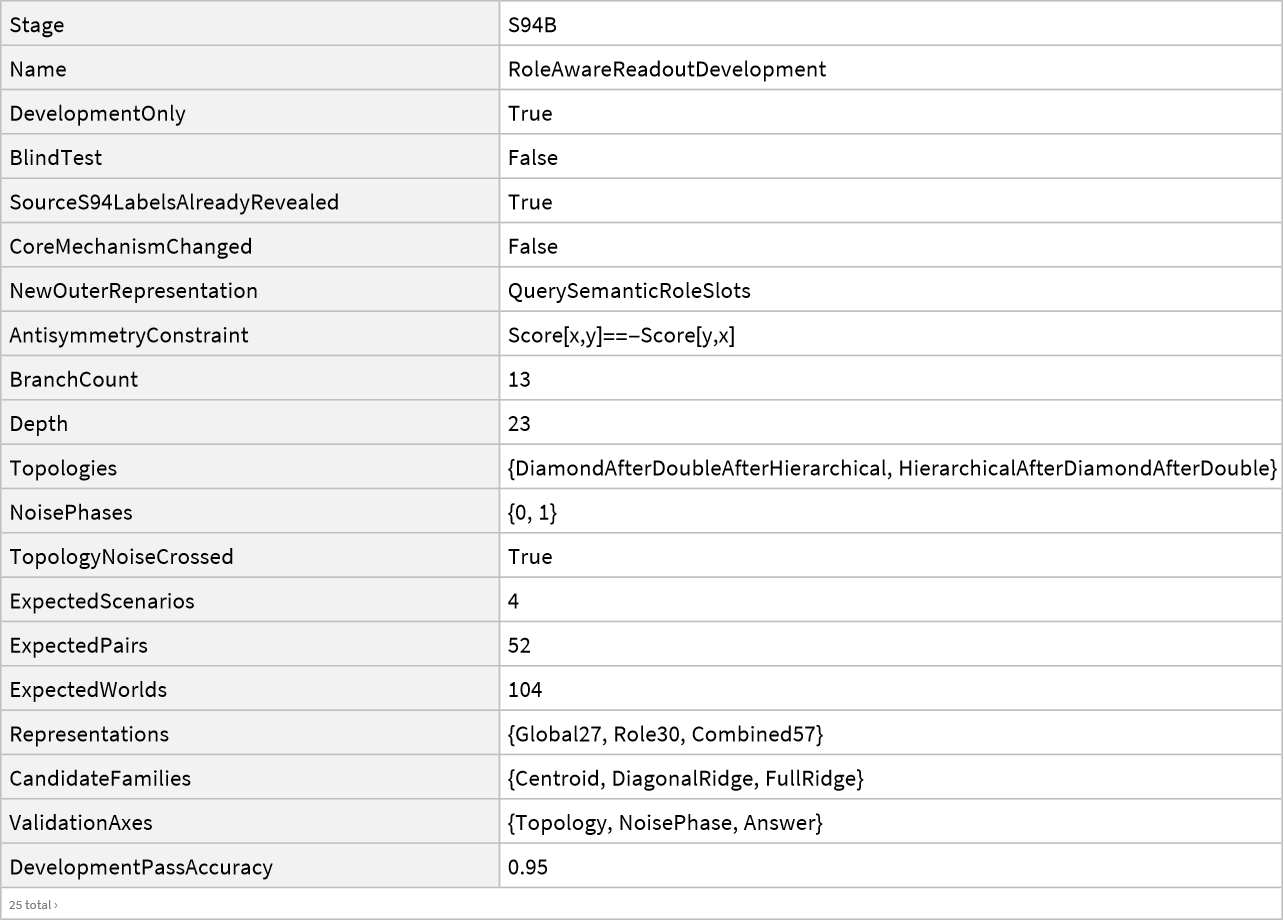

In [1570]:
ClearAll[T94B,Case94B,ReferenceAction94B,NodeRole94B,EncodePair94B,
DiamondAfterDoubleAfterHierarchical94B,
HierarchicalAfterDiamondAfterDouble94B,TopologyTransform94B,
ExpectedContractions94B,RoleStats94B,RoleAwareVector94B,
PrepareWorld94B,PrepareScenario94B,RepresentationVector94B,
FitAntisymmetricReadout94B,ScoreAntisymmetricReadout94B,
FoldMemberQ94B,EvaluateCandidate94B,TestDefinitionBundle94B,
ReadoutDefinitionBundle94B];

T94B[depth_Integer,target_String,answer_Integer,seed_Integer,
branchCount_Integer,noisePhase_Integer]:=Module[
{bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,main,perm,anc,
branchAction,i},
bb=1000000000 seed;K=bb+1;
c=Table[bb+100+i,{i,branchCount}];v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[Table[{DirectedEdge[K,c[[i]]],DirectedEdge[c[[i]],v[[i]]]},{i,branchCount}],1];
Do[ib=bb+20000000 i;m=ib+1;safe=ib+2;u=ib+3;dummy=ib+4;
r1=ib+10;r2=ib+20;wrong=c[[1+Mod[i,branchCount]]];
main=Join[P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],{DirectedEdge[r1,m],DirectedEdge[r2,m]},
P59[q[[i]],safe,depth+1,ib+3000000]];
branchAction=If[i===answer,target,If[EvenQ[i+noisePhase],"Continue","Stop"]];
perm=If[branchAction==="Continue",
{DirectedEdge[m,c[[i]]],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]},
{DirectedEdge[m,wrong],DirectedEdge[safe,c[[i]]],DirectedEdge[u,dummy]}];
anc=Join[A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]];
e=Join[e,main,perm,anc];AppendTo[f,m],{i,branchCount}];
{{Union[e],q,K,v,c,f},answer}];

Case94B[depth_Integer,answer_Integer,target_String,
topologyIndex_Integer,noisePhase_Integer]:=T94B[depth,target,answer,
94200000+1000 topologyIndex+100 depth+noisePhase,13,noisePhase];

ReferenceAction94B[c_List]:=Module[{x=c[[1]],answer=c[[2]],branchCount,e,m,
safe,u,dummy,correct,wrong,continueEdges,stopEdges},
branchCount=Length[x[[6]]];e=x[[1]];m=x[[6,answer]];safe=m+1;u=m+2;
dummy=m+3;correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={DirectedEdge[m,correct],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]};
stopEdges={DirectedEdge[m,wrong],DirectedEdge[safe,correct],DirectedEdge[u,dummy]};
Which[And@@(MemberQ[e,#]&/@continueEdges),"Continue",
And@@(MemberQ[e,#]&/@stopEdges),"Stop",True,"Undefined"]];

NodeRole94B[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];branchCount=Length[x[[6]]];m=x[[6,answer]];
correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];dummy=m+3;
querySources={m,m+1,m+2};queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",True,"OtherReject"];
<|"Role"->role,"QueryBranchRelated"->MemberQ[queryBranch,originalNode]|>];

EncodePair94B[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[{<|"Grammar"->"S94BRoleAwareDevelopment",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled","StatePairs"->{pair}|>},
frozenCandidate86E["EncoderParams"],frozenCandidate86E["K"]];
First[encoded["Codes"]]];

DiamondAfterDoubleAfterHierarchical94B[c_List]:=
DiamondIn72[DoubleDiamondIn79[HierarchicalDiamondIn80[c]]];
HierarchicalAfterDiamondAfterDouble94B[c_List]:=
HierarchicalDiamondIn80[DiamondIn72[DoubleDiamondIn79[c]]];
TopologyTransform94B[topology_String,c_List]:=Switch[topology,
"DiamondAfterDoubleAfterHierarchical",DiamondAfterDoubleAfterHierarchical94B[c],
"HierarchicalAfterDiamondAfterDouble",HierarchicalAfterDiamondAfterDouble94B[c],
_,$Failed];
ExpectedContractions94B[baseCase_List]:=6 DecisionIncomingEdgeCount79B[baseCase];

roleOrder94B={"QueriedDecision","QueriedMediatorSource",
"QueriedCorrectDestination","QueriedWrongDestination","QueriedDummyDestination"};
RoleStats94B[observations_List,role_String]:=Module[{selected,codes,a,b},
selected=Select[observations,SameQ[Lookup[#,"Role"],role]&];
codes=Lookup[selected,"Code",{}];
If[Length[codes]===0,Return[{0,0,0,0,0,0}]];
a=codes[[All,1]];b=codes[[All,2]];
{Length[codes],Total[a],Total[b],Total[a^2],Total[b^2],Total[Abs[a-b]]}];
RoleAwareVector94B[observations_List]:=Flatten[
RoleStats94B[observations,#]&/@roleOrder94B];

PrepareWorld94B[topology_String,topologyIndex_Integer,noisePhase_Integer,
depth_Integer,target_String,answer_Integer]:=Module[
{baseCase,topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,observations,
queryObservations,originalNode,pair,roleInfo,globalVector,roleVector,
nonQueryContinue,nonQueryStop},
baseCase=Case94B[depth,answer,target,topologyIndex,noisePhase];
topologyCase=TopologyTransform94B[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions94B[baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[Length[trace["Rejects"]]===0,{},
DeleteDuplicates[trace["Rejects"][[All,2]]]];
observations=Map[Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole94B[originalNode,canonicalCase,answer];
<|"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair94B[pair]|>],packedNodes];
queryObservations=Select[observations,TrueQ[Lookup[#,"QueryBranchRelated",False]]&];
globalVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
roleVector=RoleAwareVector94B[queryObservations];
nonQueryContinue=Count[DeleteCases[Range[13],answer],i_/;EvenQ[i+noisePhase]];
nonQueryStop=12-nonQueryContinue;
<|"Topology"->topology,"TopologyIndex"->topologyIndex,
"NoisePhase"->noisePhase,"Depth"->depth,"Answer"->answer,
"Target"->target,"ReferenceAction"->ReferenceAction94B[canonicalCase],
"NonQueryContinueBranches"->nonQueryContinue,
"NonQueryStopBranches"->nonQueryStop,
"GlobalVector"->globalVector,"RoleVector"->roleVector,
"QueryObservationCount"->Length[queryObservations],
"QueryRoleCounts"->AssociationMap[
Count[Lookup[queryObservations,"Role"],#]&,roleOrder94B],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],
expectedContractions],"ProtectedNodesPreserved"->
canonicalization["ProtectedNodesPreserved"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"TraceSeconds"->traceSeconds|>];

PrepareScenario94B[topology_String,topologyIndex_Integer,
noisePhase_Integer,depth_Integer]:=Module[{continueWorlds,stopWorlds,pairs},
continueWorlds=Table[PrepareWorld94B[topology,topologyIndex,noisePhase,
depth,"Continue",answer],{answer,13}];
stopWorlds=Table[PrepareWorld94B[topology,topologyIndex,noisePhase,
depth,"Stop",answer],{answer,13}];
pairs=MapThread[Function[{continue,stop},<|
"Topology"->topology,"TopologyIndex"->topologyIndex,
"NoisePhase"->noisePhase,"Depth"->depth,"Answer"->continue["Answer"],
"ContinueWorld"->continue,"StopWorld"->stop,
"GlobalDifference"->continue["GlobalVector"]-stop["GlobalVector"],
"RoleDifference"->continue["RoleVector"]-stop["RoleVector"],
"CombinedDifference"->Join[
continue["GlobalVector"]-stop["GlobalVector"],
continue["RoleVector"]-stop["RoleVector"]],
"ReferenceRelationCorrect"->And[
SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]]|>],{continueWorlds,stopWorlds}];
<|"Topology"->topology,"TopologyIndex"->topologyIndex,
"NoisePhase"->noisePhase,"Depth"->depth,"Pairs"->pairs,
"ContinueWorlds"->continueWorlds,"StopWorlds"->stopWorlds|>];

RepresentationVector94B[row_Association,representation_String]:=Switch[
representation,"Global27",row["GlobalDifference"],
"Role30",row["RoleDifference"],
"Combined57",row["CombinedDifference"],_,$Failed];

FitAntisymmetricReadout94B[rows_List,representation_String,
family_String,lambda_?NumericQ]:=Module[
{differences,scale,z,mu,covariance,variance,weights},
differences=RepresentationVector94B[#,representation]&/@rows;
If[!MatrixQ[differences,NumericQ],Return[$Failed]];
scale=Sqrt[Mean[#^2]]&/@Transpose[differences];
scale=Map[If[!NumericQ[#]||Abs[N[#]]<10^-12,1.,N[#]]&,scale];
z=N[(#/scale)&/@differences];mu=Mean[z];
covariance=Transpose[z].z/Length[z]-Outer[Times,mu,mu];
variance=Diagonal[covariance];
weights=Switch[family,"Centroid",mu,
"DiagonalRidge",mu/(variance+lambda),
"FullRidge",Quiet@Check[
LinearSolve[covariance+lambda IdentityMatrix[Length[mu]],mu],$Failed],
_,$Failed];
If[!VectorQ[weights,NumericQ],Return[$Failed]];
<|"Representation"->representation,"Family"->family,
"Lambda"->lambda,"Scale"->scale,"Weights"->weights|>];

ScoreAntisymmetricReadout94B[model_Association,difference_List]:=
N[Total[model["Weights"] (difference/model["Scale"])]];
FoldMemberQ94B[row_Association,fold_Association]:=Switch[fold["Axis"],
"Topology",SameQ[row["Topology"],fold["Heldout"]],
"NoisePhase",SameQ[row["NoisePhase"],fold["Heldout"]],
"Answer",SameQ[row["Answer"],fold["Heldout"]],_,False];

EvaluateCandidate94B[rows_List,folds_List,spec_Association]:=Module[
{foldRows},foldRows=Map[Function[fold,Module[{train,test,model,scores},
test=Select[rows,TrueQ[FoldMemberQ94B[#,fold]]&];
train=Select[rows,!TrueQ[FoldMemberQ94B[#,fold]]&];
model=FitAntisymmetricReadout94B[train,spec["Representation"],
spec["Family"],spec["Lambda"]];
scores=If[AssociationQ[model],ScoreAntisymmetricReadout94B[model,
RepresentationVector94B[#,spec["Representation"]]]&/@test,{}];
<|"Axis"->fold["Axis"],"Heldout"->fold["Heldout"],
"Cases"->Length[test],"Correct"->Count[scores,x_/;x>0],
"ZeroScores"->Count[scores,x_/;Abs[x]<10^-12],
"Accuracy"->If[Length[test]>0,N[Count[scores,x_/;x>0]/Length[test]],0.],
"MinimumMargin"->If[Length[scores]>0,Min[scores],-Infinity]|>]],folds];
Join[spec,<|"Folds"->Length[foldRows],"Cases"->Total@Lookup[foldRows,"Cases"],
"Correct"->Total@Lookup[foldRows,"Correct"],
"Accuracy"->N[Total@Lookup[foldRows,"Correct"]/
Total@Lookup[foldRows,"Cases"]],
"WorstFoldAccuracy"->Min@Lookup[foldRows,"Accuracy"],
"ZeroScores"->Total@Lookup[foldRows,"ZeroScores"],
"MinimumMargin"->Min@Lookup[foldRows,"MinimumMargin"],
"FoldResults"->foldRows|>]];

TestDefinitionBundle94B[]:={DownValues[T94B],DownValues[Case94B],
DownValues[ReferenceAction94B],DownValues[NodeRole94B],DownValues[EncodePair94B],
DownValues[DiamondAfterDoubleAfterHierarchical94B],
DownValues[HierarchicalAfterDiamondAfterDouble94B],
DownValues[TopologyTransform94B],DownValues[ExpectedContractions94B],
DownValues[RoleStats94B],DownValues[RoleAwareVector94B],
DownValues[PrepareWorld94B],DownValues[PrepareScenario94B]};
ReadoutDefinitionBundle94B[]:={DownValues[RepresentationVector94B],
DownValues[FitAntisymmetricReadout94B],DownValues[ScoreAntisymmetricReadout94B],
DownValues[FoldMemberQ94B],DownValues[EvaluateCandidate94B]};

testDefinitionHashBefore94B=Hash[TestDefinitionBundle94B[],"SHA256","HexString"];
readoutDefinitionHashBefore94B=Hash[ReadoutDefinitionBundle94B[],
"SHA256","HexString"];
protocol94B=<|"Stage"->"S94B","Name"->"RoleAwareReadoutDevelopment",
"DevelopmentOnly"->True,"BlindTest"->False,
"SourceS94LabelsAlreadyRevealed"->True,
"CoreMechanismChanged"->False,
"NewOuterRepresentation"->"QuerySemanticRoleSlots",
"AntisymmetryConstraint"->"Score[x,y]==-Score[y,x]",
"BranchCount"->13,"Depth"->23,
"Topologies"->{"DiamondAfterDoubleAfterHierarchical",
"HierarchicalAfterDiamondAfterDouble"},
"NoisePhases"->{0,1},"TopologyNoiseCrossed"->True,
"ExpectedScenarios"->4,"ExpectedPairs"->52,"ExpectedWorlds"->104,
"Representations"->{"Global27","Role30","Combined57"},
"CandidateFamilies"->{"Centroid","DiagonalRidge","FullRidge"},
"ValidationAxes"->{"Topology","NoisePhase","Answer"},
"DevelopmentPassAccuracy"->0.95,"DevelopmentPassWorstFoldAccuracy"->0.8,
"CandidateFrozenAtThisStage"->False|>;
protocolHash94B=Hash[Normal[protocol94B],"SHA256","HexString"];
Dataset[{Join[protocol94B,<|"ProtocolHash"->protocolHash94B,
"TestDefinitionHash"->testDefinitionHashBefore94B,
"ReadoutDefinitionHash"->readoutDefinitionHashBefore94B|>]}]


Dataset[{<|Scenarios -> 4, Pairs -> 52, Worlds -> 104, ReferenceRelationsCorrect -> 52, 
 
>     MixedContextWorlds -> 104, CanonicalCaseExactlyBase -> 104, 
 
>     ContractionCountCorrect -> 104, ProtectedNodesPreserved -> 104, 
 
>     ValidGlobalVectors -> 104, ValidRoleVectors -> 104, TerminatedNaturally -> 104, 
 
>     HitSafetyCap -> 0, OldFrozenPairCorrect -> 0, OldFrozenUnknownPredictions -> 104, 
 
>     TotalTraceSeconds -> 21.2007|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Scenarios, Pairs, Worlds, 
 
>      ReferenceRelationsCorrect, MixedContextWorlds, CanonicalCaseExactlyBase, 
 
>      ContractionCountCorrect, ProtectedNodesPreserved, ValidGlobalVectors, 
 
>      ValidRoleVectors, TerminatedNaturally, HitSafetyCap, OldFrozenPairCorrect, 
 
>      OldFrozenUnknownPredictions, TotalTraceSeconds}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real]}], 1], 
 
>   <||>]
Dataset[{<|Representation -> Role30, Family -> FullRidge, Lambda -> 100., Folds -> 17, 
 
>     Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -0.0315701|>, 
 
>    <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 100., Folds -> 17, 
 
>     Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -0.0316404|>, 
 
>    <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 10., Folds -> 17, 
 
>     Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -0.295089|>, 
 
>    <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 1., Folds -> 17, 
 
>     Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -1.76469|>, 
 
>    <|Representation -> Role30, Family -> Centroid, Lambda -> 1., Folds -> 17, 
 
>     Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -3.18965|>, 
 
>    <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 0.1, Folds -> 17, 
 
>     Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -3.52277|>, 
 
>    <|Representation -> Combined57, Family -> FullRidge, Lambda -> 100., Folds -> 17, 
 
>     Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -0.0648145|>, 
 
>    <|Representation -> Combined57, Family -> DiagonalRidge, Lambda -> 100., 
 
>     Folds -> 17, Cases -> 156, Correct -> 130, Accuracy -> 0.833333, 
 
>     WorstFoldAccuracy -> 0.5, ZeroScores -> 0, MinimumMargin -> -0.0648355|>, 
 
>    <|Representation -> Role30, Family -> FullRidge, Lambda -> 10., Folds -> 17, 
 
>     Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -0.290952|>, 
 
>    <|Representation -> Global27, Family -> FullRidge, Lambda -> 10., Folds -> 17, 
 
>     Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -0.317648|>, 
 
>    <|Representation -> Combined57, Family -> FullRidge, Lambda -> 10., Folds -> 17, 
 
>     Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>     ZeroScores -> 0, MinimumMargin -> -0.599395|>, 
 
>    <|Representation -> Combined57, Family -> DiagonalRidge, Lambda -> 10., 
 
>     Folds -> 17, Cases -> 156, Correct -> 130, Accuracy -> 0.833333, 
 
>     WorstFo
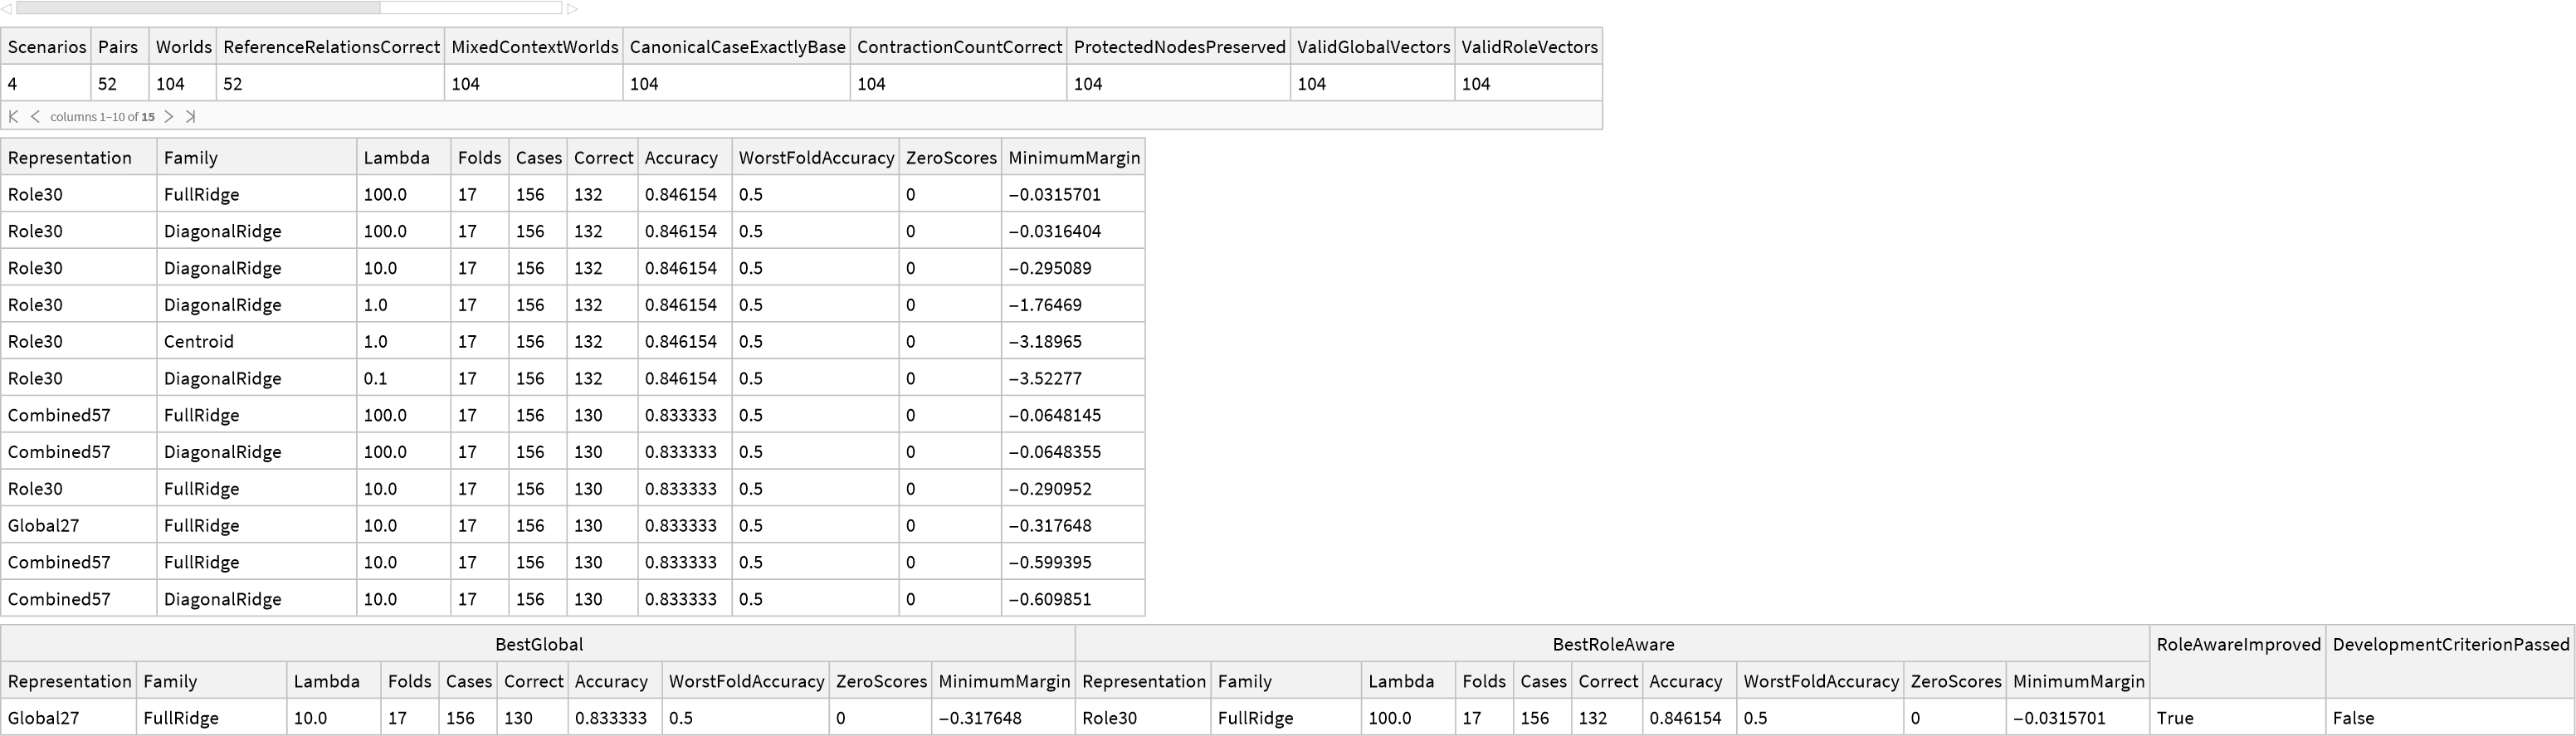

In [1601]:
developmentTopologies94B={"DiamondAfterDoubleAfterHierarchical",
"HierarchicalAfterDiamondAfterDouble"};
developmentScenarios94B=Flatten[Table[
PrepareScenario94B[topology,topologyIndex,noisePhase,23],
{topologyIndex,Length[developmentTopologies94B]},
{topology,{developmentTopologies94B[[topologyIndex]]}},
{noisePhase,{0,1}}],2];
developmentPairs94B=Flatten[Lookup[developmentScenarios94B,"Pairs"],1];
developmentWorlds94B=Join[
Flatten[Lookup[developmentScenarios94B,"ContinueWorlds"],1],
Flatten[Lookup[developmentScenarios94B,"StopWorlds"],1]];

folds94B=Join[
Map[<|"Axis"->"Topology","Heldout"->#|>&,developmentTopologies94B],
Map[<|"Axis"->"NoisePhase","Heldout"->#|>&,{0,1}],
Map[<|"Axis"->"Answer","Heldout"->#|>&,Range[13]]];
representations94B={"Global27","Role30","Combined57"};
candidateSpecs94B=Join[
Map[<|"Representation"->#,"Family"->"Centroid","Lambda"->1.|>&,
representations94B],
Flatten[Table[<|"Representation"->representation,"Family"->family,
"Lambda"->lambda|>,{representation,representations94B},
{family,{"DiagonalRidge","FullRidge"}},
{lambda,{0.1,1.,10.,100.}}],Infinity]];
candidateResults94B=Map[
EvaluateCandidate94B[developmentPairs94B,folds94B,#]&,candidateSpecs94B];
candidateRanking94B=SortBy[candidateResults94B,{
(-Lookup[#,"Accuracy"])&,(-Lookup[#,"WorstFoldAccuracy"])&,
(-Lookup[#,"MinimumMargin"])&}];
bestCandidate94B=First[candidateRanking94B];
bestGlobal94B=First@SortBy[Select[candidateRanking94B,
SameQ[Lookup[#,"Representation"],"Global27"]&],{
(-Lookup[#,"Accuracy"])&,(-Lookup[#,"WorstFoldAccuracy"])&}];
bestRoleAware94B=First@SortBy[Select[candidateRanking94B,
MemberQ[{"Role30","Combined57"},Lookup[#,"Representation"]]&],{
(-Lookup[#,"Accuracy"])&,(-Lookup[#,"WorstFoldAccuracy"])&}];

oldPairRows94B=Map[Function[pair,Module[{forward,reverse},
forward=TCCTPredictOrderedPairVectorsS92B[
pair["ContinueWorld"]["GlobalVector"],pair["StopWorld"]["GlobalVector"],
pairDecoderLoaded94B];
reverse=TCCTPredictOrderedPairVectorsS92B[
pair["StopWorld"]["GlobalVector"],pair["ContinueWorld"]["GlobalVector"],
pairDecoderLoaded94B];
<|"Forward"->forward,"Reverse"->reverse,
"Correct"->And[SameQ[forward,"FirstContinue"],
SameQ[reverse,"FirstStop"]]|>]],developmentPairs94B];

summary94B=<|"Scenarios"->Length[developmentScenarios94B],
"Pairs"->Length[developmentPairs94B],"Worlds"->Length[developmentWorlds94B],
"ReferenceRelationsCorrect"->Count[developmentPairs94B,p_/;
TrueQ[p["ReferenceRelationCorrect"]]],
"MixedContextWorlds"->Count[developmentWorlds94B,w_/;And[
w["NonQueryContinueBranches"]>0,w["NonQueryStopBranches"]>0]],
"CanonicalCaseExactlyBase"->Count[developmentWorlds94B,w_/;
TrueQ[w["CanonicalCaseExactlyBase"]]],
"ContractionCountCorrect"->Count[developmentWorlds94B,w_/;
TrueQ[w["ContractionCountCorrect"]]],
"ProtectedNodesPreserved"->Count[developmentWorlds94B,w_/;
TrueQ[w["ProtectedNodesPreserved"]]],
"ValidGlobalVectors"->Count[developmentWorlds94B,w_/;
VectorQ[w["GlobalVector"],IntegerQ]&&Length[w["GlobalVector"]]===27],
"ValidRoleVectors"->Count[developmentWorlds94B,w_/;
VectorQ[w["RoleVector"],IntegerQ]&&Length[w["RoleVector"]]===30],
"TerminatedNaturally"->Count[developmentWorlds94B,w_/;
TrueQ[w["TerminatedNaturally"]]],
"HitSafetyCap"->Count[developmentWorlds94B,w_/;TrueQ[w["HitSafetyCap"]]],
"OldFrozenPairCorrect"->Count[oldPairRows94B,p_/;TrueQ[p["Correct"]]],
"OldFrozenUnknownPredictions"->Total[
Count[Lookup[oldPairRows94B,#],"Unknown"]&/@{"Forward","Reverse"}],
"TotalTraceSeconds"->Total@Lookup[developmentWorlds94B,"TraceSeconds"]|>;

testValidityPassed94B=And[
SameQ[summary94B["Scenarios"],4],SameQ[summary94B["Pairs"],52],
SameQ[summary94B["Worlds"],104],
SameQ[summary94B["ReferenceRelationsCorrect"],52],
SameQ[summary94B["MixedContextWorlds"],104],
SameQ[summary94B["CanonicalCaseExactlyBase"],104],
SameQ[summary94B["ContractionCountCorrect"],104],
SameQ[summary94B["ProtectedNodesPreserved"],104],
SameQ[summary94B["ValidGlobalVectors"],104],
SameQ[summary94B["ValidRoleVectors"],104],
SameQ[summary94B["TerminatedNaturally"],104],
SameQ[summary94B["HitSafetyCap"],0],
SameQ[Length[folds94B],17],SameQ[Length[candidateResults94B],27]];
roleAwareImproved94B=And[
bestRoleAware94B["Accuracy"]>bestGlobal94B["Accuracy"],
bestRoleAware94B["WorstFoldAccuracy"]>=bestGlobal94B["WorstFoldAccuracy"]];
developmentCriterionPassed94B=And[TrueQ[testValidityPassed94B],
MemberQ[{"Role30","Combined57"},bestCandidate94B["Representation"]],
bestCandidate94B["Accuracy"]>=0.95,
bestCandidate94B["WorstFoldAccuracy"]>=0.8,
SameQ[bestCandidate94B["ZeroScores"],0]];

Column[{Dataset[{summary94B}],
Dataset[KeyDrop[#,"FoldResults"]&/@Take[candidateRanking94B,UpTo[12]]],
Dataset[{<|"BestGlobal"->KeyDrop[bestGlobal94B,"FoldResults"],
"BestRoleAware"->KeyDrop[bestRoleAware94B,"FoldResults"],
"RoleAwareImproved"->roleAwareImproved94B,
"DevelopmentCriterionPassed"->developmentCriterionPassed94B|>}]}]


Dataset[{<|Stage -> S94B, Name -> RoleAwareReadoutDevelopment, DevelopmentOnly -> True, 
 
>     BlindTest -> False, UsesRevealedS94Labels -> True, MayClaimBlindResult -> False, 
 
>     ProtocolHash -> 376cbf7e8a5d1fe039dd64323f1cca4be522e48d34e4a5248872082b4362e9af, 
 
>     Scenarios -> 4, Pairs -> 52, Worlds -> 104, OldFrozenPairCorrect -> 0, 
 
>     OldFrozenUnknownPredictions -> 104, 
 
>     BestGlobal -> 
 
>      <|Representation -> Global27, Family -> FullRidge, Lambda -> 10., Folds -> 17, 
 
>       Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>       ZeroScores -> 0, MinimumMargin -> -0.317648|>, 
 
>     BestRoleAware -> 
 
>      <|Representation -> Role30, Family -> FullRidge, Lambda -> 100., Folds -> 17, 
 
>       Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>       ZeroScores -> 0, MinimumMargin -> -0.0315701|>, 
 
>     BestOverall -> 
 
>      <|Representation -> Role30, Family -> FullRidge, Lambda -> 100., Folds -> 17, 
 
>       Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>       ZeroScores -> 0, MinimumMargin -> -0.0315701|>, 
 
>     CandidateRankingTop12 -> 
 
>      {<|Representation -> Role30, Family -> FullRidge, Lambda -> 100., Folds -> 17, 
 
>        Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -0.0315701|>, 
 
>       <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 100., 
 
>        Folds -> 17, Cases -> 156, Correct -> 132, Accuracy -> 0.846154, 
 
>        WorstFoldAccuracy -> 0.5, ZeroScores -> 0, MinimumMargin -> -0.0316404|>, 
 
>       <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 10., Folds -> 17, 
 
>        Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -0.295089|>, 
 
>       <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 1., Folds -> 17, 
 
>        Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -1.76469|>, 
 
>       <|Representation -> Role30, Family -> Centroid, Lambda -> 1., Folds -> 17, 
 
>        Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -3.18965|>, 
 
>       <|Representation -> Role30, Family -> DiagonalRidge, Lambda -> 0.1, Folds -> 17, 
 
>        Cases -> 156, Correct -> 132, Accuracy -> 0.846154, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -3.52277|>, 
 
>       <|Representation -> Combined57, Family -> FullRidge, Lambda -> 100., 
 
>        Folds -> 17, Cases -> 156, Correct -> 130, Accuracy -> 0.833333, 
 
>        WorstFoldAccuracy -> 0.5, ZeroScores -> 0, MinimumMargin -> -0.0648145|>, 
 
>       <|Representation -> Combined57, Family -> DiagonalRidge, Lambda -> 100., 
 
>        Folds -> 17, Cases -> 156, Correct -> 130, Accuracy -> 0.833333, 
 
>        WorstFoldAccuracy -> 0.5, ZeroScores -> 0, MinimumMargin -> -0.0648355|>, 
 
>       <|Representation -> Role30, Family -> FullRidge, Lambda -> 10., Folds -> 17, 
 
>        Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -0.290952|>, 
 
>       <|Representation -> Global27, Family -> FullRidge, Lambda -> 10., Folds -> 17, 
 
>        Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -0.317648|>, 
 
>       <|Representation -> Combined57, Family -> FullRidge, Lambda -> 10., Folds -> 17, 
 
>        Cases -> 156, Correct -> 130, Accuracy -> 0.833333, WorstFoldAccuracy -> 0.5, 
 
>        ZeroScores -> 0, MinimumMargin -> -0.599395|>, 
 
>       <|Representation -> Combined57, Family -> DiagonalRidge, Lambda -> 10., 
 
>        Folds -> 17, Cases -> 156, Correct -> 130, Accuracy -
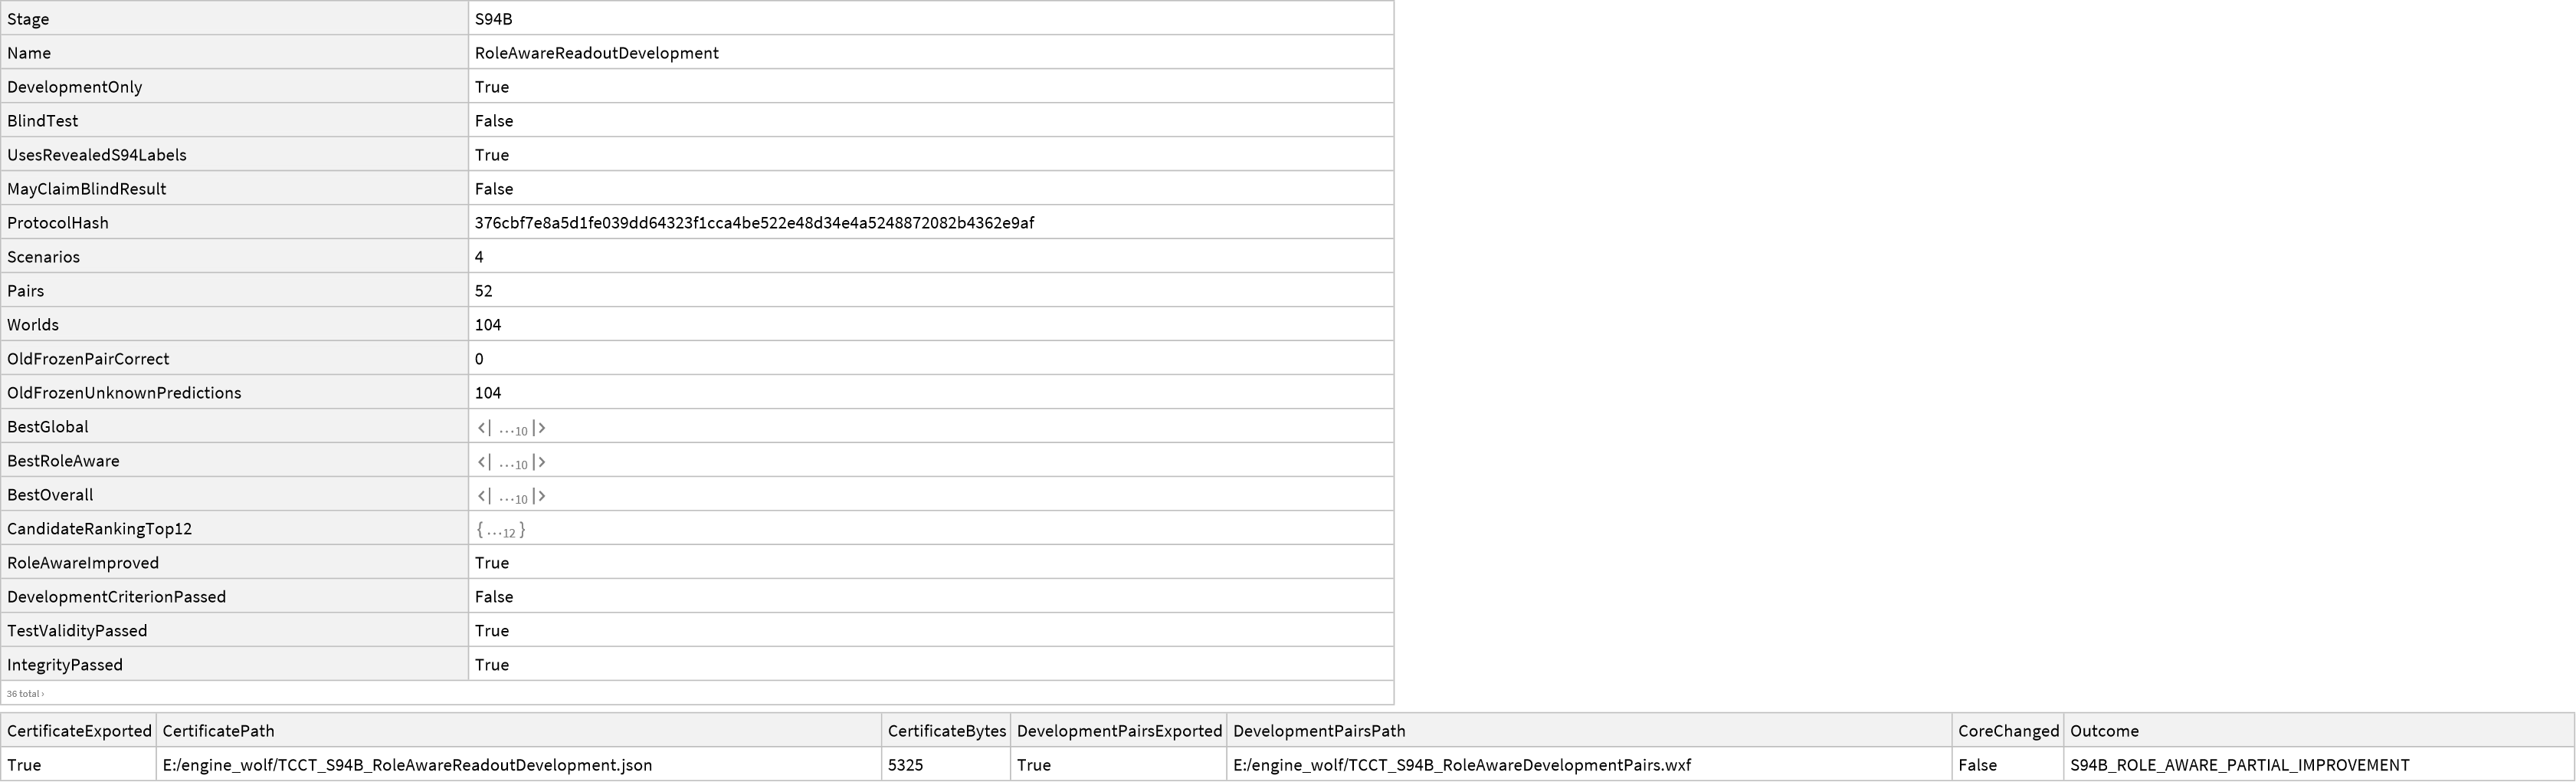

In [1619]:
modelHashAfter94B=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashAfter94B=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
baseDecoderObjectHashAfter94B=Hash[Normal[baseDecoderRaw94B],"SHA256","HexString"];
pairDecoderObjectHashAfter94B=Hash[Normal[pairDecoderRaw94B],"SHA256","HexString"];
coreHashAfter94B=Hash[CoreDefinitionBundle94B[],"SHA256","HexString"];
canonicalizerHashAfter94B=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashAfter94B=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashAfter94B=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
baseRuntimeDefinitionHashAfter94B=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
pairRuntimeDefinitionHashAfter94B=Hash[
PairRuntimeDefinitionBundle94B[],"SHA256","HexString"];
testDefinitionHashAfter94B=Hash[TestDefinitionBundle94B[],"SHA256","HexString"];
readoutDefinitionHashAfter94B=Hash[ReadoutDefinitionBundle94B[],
"SHA256","HexString"];
fileHashesAfter94B=FileSHA256Hex94B/@requiredFiles94B;

integrityPassed94B=And[
SameQ[modelHashBefore94B,modelHashAfter94B],
SameQ[k33ObjectHashBefore94B,k33ObjectHashAfter94B],
SameQ[baseDecoderObjectHashBefore94B,baseDecoderObjectHashAfter94B],
SameQ[pairDecoderObjectHashBefore94B,pairDecoderObjectHashAfter94B],
SameQ[coreHashBefore94B,coreHashAfter94B],
SameQ[canonicalizerHashBefore94B,canonicalizerHashAfter94B],
SameQ[interventionHashBefore94B,interventionHashAfter94B],
SameQ[topologyPrimitiveHashBefore94B,topologyPrimitiveHashAfter94B],
SameQ[baseRuntimeDefinitionHashBefore94B,baseRuntimeDefinitionHashAfter94B],
SameQ[pairRuntimeDefinitionHashBefore94B,pairRuntimeDefinitionHashAfter94B],
SameQ[testDefinitionHashBefore94B,testDefinitionHashAfter94B],
SameQ[readoutDefinitionHashBefore94B,readoutDefinitionHashAfter94B],
SameQ[fileHashesBefore94B,fileHashesAfter94B]];

developmentArtifact94B=<|"Stage"->"S94B",
"DevelopmentOnly"->True,"SourceS94LabelsAlreadyRevealed"->True,
"ProtocolHash"->protocolHash94B,
"TestDefinitionHash"->testDefinitionHashAfter94B,
"ReadoutDefinitionHash"->readoutDefinitionHashAfter94B,
"Rows"->Map[KeyTake[#,{"Topology","TopologyIndex","NoisePhase","Depth",
"Answer","GlobalDifference","RoleDifference","CombinedDifference"}]&,
developmentPairs94B]|>;
developmentArtifactObjectHash94B=Hash[Normal[developmentArtifact94B],
"SHA256","HexString"];
developmentArtifactExportResult94B=Quiet@Check[
Export[developmentPairsPath94B,developmentArtifact94B,"WXF"],$Failed];
developmentArtifactExported94B=StringQ[developmentArtifactExportResult94B]&&
FileExistsQ[developmentPairsPath94B]&&FileByteCount[developmentPairsPath94B]>0;
developmentArtifactFileHash94B=If[TrueQ[developmentArtifactExported94B],
FileSHA256Hex94B[developmentPairsPath94B],Missing[]];

compactRanking94B=Map[KeyDrop[#,"FoldResults"]&,
Take[candidateRanking94B,UpTo[12]]];
resultPayload94B=<|"Stage"->"S94B",
"Name"->"RoleAwareReadoutDevelopment","DevelopmentOnly"->True,
"BlindTest"->False,"UsesRevealedS94Labels"->True,
"MayClaimBlindResult"->False,"ProtocolHash"->protocolHash94B,
"Scenarios"->summary94B["Scenarios"],"Pairs"->summary94B["Pairs"],
"Worlds"->summary94B["Worlds"],
"OldFrozenPairCorrect"->summary94B["OldFrozenPairCorrect"],
"OldFrozenUnknownPredictions"->summary94B["OldFrozenUnknownPredictions"],
"BestGlobal"->KeyDrop[bestGlobal94B,"FoldResults"],
"BestRoleAware"->KeyDrop[bestRoleAware94B,"FoldResults"],
"BestOverall"->KeyDrop[bestCandidate94B,"FoldResults"],
"CandidateRankingTop12"->compactRanking94B,
"RoleAwareImproved"->roleAwareImproved94B,
"DevelopmentCriterionPassed"->developmentCriterionPassed94B,
"TestValidityPassed"->testValidityPassed94B,
"IntegrityPassed"->integrityPassed94B,
"DevelopmentArtifactExported"->developmentArtifactExported94B,
"DevelopmentArtifactObjectHash"->developmentArtifactObjectHash94B,
"DevelopmentArtifactFileHash"->developmentArtifactFileHash94B,
"CandidateFrozen"->False,"DynamicModulusSelected"->False,
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore94B,modelHashAfter94B],
"FrozenPairDecoderChanged"->!SameQ[pairDecoderObjectHashBefore94B,
pairDecoderObjectHashAfter94B],
"CoreChanged"->!SameQ[coreHashBefore94B,coreHashAfter94B],
"CanonicalizerChanged"->!SameQ[canonicalizerHashBefore94B,
canonicalizerHashAfter94B],
"InterventionCoreChanged"->!SameQ[interventionHashBefore94B,
interventionHashAfter94B],
"DeduplicationMechanismChanged"->!SameQ[coreHashBefore94B,coreHashAfter94B],
"UndirectedFreezeMechanismChanged"->!SameQ[coreHashBefore94B,coreHashAfter94B],
"TotalTraceSeconds"->summary94B["TotalTraceSeconds"],
"Outcome"->Which[!TrueQ[testValidityPassed94B]||!TrueQ[integrityPassed94B]||
!TrueQ[developmentArtifactExported94B],"S94B_INVALID_DEVELOPMENT_RUN",
TrueQ[developmentCriterionPassed94B],
"S94B_ROLE_AWARE_DEVELOPMENT_PASS_READY_FOR_CONFIRMATION",
TrueQ[roleAwareImproved94B],"S94B_ROLE_AWARE_PARTIAL_IMPROVEMENT",
True,"S94B_NO_CONTEXT_INVARIANT_READOUT_FOUND"],
"SuggestedNextStage"->Which[TrueQ[developmentCriterionPassed94B],
"S94C_INDEPENDENT_DEVELOPMENT_CONFIRMATION_BEFORE_FREEZE",
TrueQ[roleAwareImproved94B],"S94C_EXPAND_ROLE_AWARE_DEVELOPMENT_CONTEXTS",
True,"S94C_REDESIGN_QUERY_ROLE_REPRESENTATION"]|>;
resultHash94B=Hash[Normal[resultPayload94B],"SHA256","HexString"];
certificate94B=Append[resultPayload94B,"ResultHash"->resultHash94B];
certificateExportResult94B=Quiet@Check[
Export[resultCertificatePath94B,certificate94B,"RawJSON"],$Failed];
certificateExported94B=StringQ[certificateExportResult94B]&&
FileExistsQ[resultCertificatePath94B]&&FileByteCount[resultCertificatePath94B]>0;

Column[{Dataset[{certificate94B}],Dataset[{<|
"CertificateExported"->certificateExported94B,
"CertificatePath"->resultCertificatePath94B,
"CertificateBytes"->If[FileExistsQ[resultCertificatePath94B],
FileByteCount[resultCertificatePath94B],0],
"DevelopmentPairsExported"->developmentArtifactExported94B,
"DevelopmentPairsPath"->developmentPairsPath94B,
"CoreChanged"->certificate94B["CoreChanged"],
"Outcome"->certificate94B["Outcome"]|>}]}]
